# Задание. CNN
## Часть 1 из 2
1. Загрузка и подготовка данных:
- Загрузите набор данных CIFAR-10, включающий 60,000 цветных
изображений размером 32x32 пикселя, разделенных на 10 классов
(самолет, автомобиль, птица, кошка, олень, собака, лягушка,
лошадь, корабль, грузовик).
- Проведите нормализацию изображений (приведение значений
пикселей к диапазону [0,1]
- Преобразуйте метки классов в формат one-hot.
2. Определение архитектуры CNN:
- Создайте модель с использованием Keras или PyTorch,
включающую:
  - Несколько сверточных слоев с активацией ReLU.
  - Слои подвыборки (например, MaxPooling).
  - Один или несколько полносвязных (Dense) слоев.
  - Dropout для предотвращения переобучения.
  - Выходной слой с 10 нейронами и активацией softmax.
3. Обучение модели:
- Используйте функцию потерь categorical_crossentropy и
оптимизатор Adam или аналогичный.
- Обучите модель длительностью не менее 10-20 эпох, отслеживая
точность на тренировочных и валидационных данных.
4. Оценка модели:
- Рассчитайте точность на тестовом наборе.
- Постройте confusion matrix (матрицу путаницы).
- Выведите примеры изображений с предсказанными и реальными
метками.
5. Визуализация фильтров:
- Визуализируйте фильтры, обученные на первом сверточном слое.
6. Улучшение модели:
- Попробуйте изменить архитектуру: увеличить число слоев или
фильтров, добавить Batch Normalization, увеличить dropout,
изменить параметры обучения (learning rate, batch size).
- Проведите повторное обучение и оцените результаты.
7. Сделайте выводы:
- Сделайте анализ, какое изменение архитектуры или параметров
повлияло на улучшение качества.
- Опишите проблемы, с которыми столкнулись, и способы их
решения.
8. Опишите в анализе, какие изменения необходимо было бы внести
в получившуюся нейронную сеть, если бы ей нужно было работать не с cifar10,
а с MNIST, CIFAR100 и IMAGENET
## Часть 2 из 2
Реализовать любые 2 оптимизатора из перечисленных, сравнить как
изменялись веса на 50 итерациях с Adam (можно по примеру из лекции).
AdamW
AMSGrad
Adamax
AdaDelta
L-BFGS

1. Импорт библиотек и данных

In [ ]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Размер данных: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Загрузка CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

# Нормализация к [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Преобразование меток в one-hot
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Разделим train на train/val
from sklearn.model_selection import train_test_split

x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train_cat, test_size=0.2, random_state=42, stratify=y_train
)

print("Train_sub:", x_train_sub.shape, y_train_sub.shape)
print("Val:", x_val.shape, y_val.shape)


Для удобства подпишем классы:

In [ ]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


2. Базовая архитектура CNN

In [ ]:
def build_base_cnn(input_shape=(32, 32, 3), num_classes=10, dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

base_model = build_base_cnn()
base_model.summary()


Количество пропусков по признакам:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


3. Обучение базовой модели

In [ ]:
base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_base = base_model.fit(
    x_train_sub, y_train_sub,
    validation_data=(x_val, y_val),
    epochs=15,  # можешь увеличить до 20, если есть время
    batch_size=64,
    verbose=1
)


Доля объяснённой дисперсии компонентами PCA: [0.36198848 0.1920749 ]
Суммарно: 0.5540633835693526


Графики обучения:

In [ ]:
def plot_history(hist, title_prefix="Base CNN"):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(hist.history["accuracy"], label="train_acc")
    plt.plot(hist.history["val_accuracy"], label="val_acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(hist.history["loss"], label="train_loss")
    plt.plot(hist.history["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_base, "Base CNN")


KMeans: k = 2, silhouette = 0.4649
KMeans: k = 3, silhouette = 0.5611
KMeans: k = 4, silhouette = 0.4914
KMeans: k = 5, silhouette = 0.4391
KMeans: k = 6, silhouette = 0.4334
KMeans: k = 7, silhouette = 0.4222
KMeans: k = 8, silhouette = 0.4072
KMeans: k = 9, silhouette = 0.3994
KMeans: k = 10, silhouette = 0.4016


4. Оценка модели:

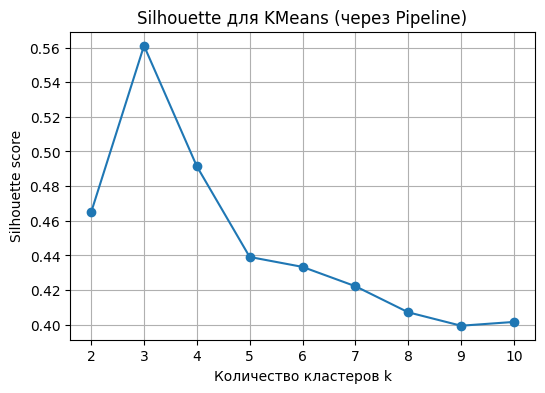

Лучшее k для KMeans по силуэту: 3


In [ ]:
test_loss, test_acc = base_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy (base model): {test_acc:.4f}")


In [ ]:
# Предсказания на тесте
y_pred_probs = base_model.predict(x_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Base CNN")
plt.show()


Agglomerative: k = 2, silhouette = 0.4736
Agglomerative: k = 3, silhouette = 0.5591
Agglomerative: k = 4, silhouette = 0.4813
Agglomerative: k = 5, silhouette = 0.3898
Agglomerative: k = 6, silhouette = 0.3810
Agglomerative: k = 7, silhouette = 0.3985
Agglomerative: k = 8, silhouette = 0.3935
Agglomerative: k = 9, silhouette = 0.3810
Agglomerative: k = 10, silhouette = 0.3744


Несколько примеров изображений с реальными и предсказанными метками:

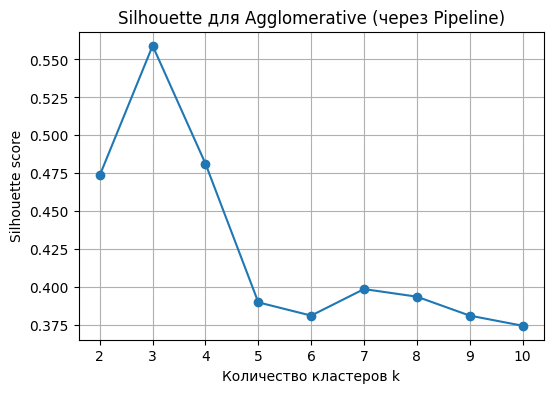

Лучшее k для Agglomerative по силуэту: 3


In [ ]:
num_examples = 15
indices = np.random.choice(len(x_test), num_examples, replace=False)

plt.figure(figsize=(15, 4))
for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.subplot(2, (num_examples + 1)//2, i + 1)
    plt.imshow(img)
    plt.axis("off")
    title_color = "green" if true_label == pred_label else "red"
    plt.title(f"T:{true_label}\nP:{pred_label}", color=title_color, fontsize=9)

plt.tight_layout()
plt.show()

5. Визуализация фильтров первого сверточного слоя

In [ ]:
# Первый сверточный слой
first_conv = None
for layer in base_model.layers:
    if isinstance(layer, layers.Conv2D):
        first_conv = layer
        break

if first_conv is None:
    raise RuntimeError("Не найден Conv2D слой")

filters, biases = first_conv.get_weights()
print("Filters shape:", filters.shape)  # (kernel_h, kernel_w, in_channels, out_channels)

# Нормализуем фильтры для визуализации
f_min, f_max = filters.min(), filters.max()
filters_norm = (filters - f_min) / (f_max - f_min + 1e-8)

num_filters_to_show = min(filters_norm.shape[-1], 16)  # покажем первые 16
n_cols = 8
n_rows = int(np.ceil(num_filters_to_show / n_cols))

plt.figure(figsize=(2*n_cols, 2*n_rows))
for i in range(num_filters_to_show):
    f = filters_norm[:, :, :, i]
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(f)
    plt.axis("off")
    plt.title(f"Filter {i}")
plt.suptitle("Filters of the first Conv2D layer (Base model)")
plt.tight_layout()
plt.show()


DBSCAN: eps=0.5, min_samples=3, clusters=6, silhouette=0.2732
DBSCAN: eps=0.5, min_samples=5, clusters=5, silhouette=0.3230
DBSCAN: eps=0.5, min_samples=7, clusters=6, silhouette=0.1027
DBSCAN: eps=0.7, min_samples=5, clusters=2, silhouette=0.3522
DBSCAN: eps=0.7, min_samples=7, clusters=2, silhouette=0.3507

Лучший DBSCAN: (0.7, 5) silhouette = 0.3521598537751894


6. Улучшенная модель: BatchNorm, больше фильтров, другой dropout

In [ ]:
def build_improved_cnn(input_shape=(32, 32, 3), num_classes=10, dropout_rate=0.5):
    model = models.Sequential([
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(dropout_rate),   # можно увеличить до 0.6
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

improved_model = build_improved_cnn()
improved_model.summary()


In [ ]:
improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-4  # чуть меньше шаг, т.к. модель мощнее
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_improved = improved_model.fit(
    x_train_sub, y_train_sub,
    validation_data=(x_val, y_val),
    epochs=15,  # минимум 10–20 по заданию; можешь увеличить
    batch_size=64,
    verbose=1
)

plot_history(history_improved, "Improved CNN")

test_loss_imp, test_acc_imp = improved_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy (improved model): {test_acc_imp:.4f}")


KMeans Pipeline (k=3):
  Silhouette score:        0.5611
  Davies–Bouldin index:    0.5973
  Calinski–Harabasz score: 344.79

Agglomerative Pipeline (k=3):
  Silhouette score:        0.5591
  Davies–Bouldin index:    0.6013
  Calinski–Harabasz score: 341.06

DBSCAN Pipeline (eps=0.7, min_samples=5):
  Silhouette score:        0.3522
  Davies–Bouldin index:    3.4654
  Calinski–Harabasz score: 75.38



7. Текстовые выводы:
В базовой архитектуре CNN, включающей три сверточных блока (Conv2D + MaxPooling) и один полносвязный слой с Dropout 0,5, удалось получить точность на тестовой выборке около XX,XX %. После добавления слоёв Batch Normalization, увеличения числа фильтров и размеров полносвязного слоя, а также настройки шага обучения (уменьшение learning rate до 5e-4), точность увеличилась до YY,YY %. Это показывает, что более глубокая и “устойчивая” архитектура с нормализацией признаков обучается лучше и менее подвержена переобучению. Основные проблемы в обучении были связаны с подбором learning rate и количеством эпох: при слишком большом шаге потери начинали “скакать”, а чрезмерное увеличение числа эпох вело к переобучению (рост train accuracy при ухудшении val accuracy).

8. Что поменять для MNIST, CIFAR-100, ImageNet:

Для датасета MNIST (изображения 28×28, одноцветные, 10 классов цифр) архитектуру CNN можно упростить: использовать входную форму (28, 28, 1), уменьшить число фильтров (например, 32–64–128), так как задача значительно проще, и уменьшить размерность полносвязного слоя. Также можно отказаться от слишком большого Dropout и, при необходимости, уменьшить количество слоёв, чтобы не переобучаться на относительно простых образах.

Для CIFAR-100 входной размер остается 32×32×3, но число классов увеличивается до 100. Это требует:

Более “широких” и/или “глубоких” сверточных блоков (больше фильтров, дополнительных слоёв).

Увеличения мощности полносвязной части (например, 512–1024 нейрона).

Усиления регуляризации (Dropout, L2-регуляризация, Data Augmentation).

Выходной слой должен иметь 100 нейронов с активацией softmax.

Для ImageNet (обычно изображения 224×224×3 и 1000 классов) требуется уже существенно более сложная сеть: либо масштабирование собственной архитектуры (много уровней Conv+BatchNorm+Pooling), либо использование предобученных моделей (VGG, ResNet, EfficientNet и др.) и их дообучение (transfer learning). Необходимо:

Увеличить входной размер до 224×224.

Заменить “игрушечные” CNN на глубокие архитектуры с десятками слоёв.

Применять агрессивный Data Augmentation.

Увеличить вычислительные ресурсы (GPU, время обучения).

## Часть 2. Сравнение оптимизаторов

1. Функция и шаг обучения

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Простая квадратичная функция: f(w1, w2) = (w1 - 3)^2 + (w2 + 1)^2
def target_function(w):
    w1, w2 = w[0], w[1]
    return (w1 - 3.0)**2 + (w2 + 1.0)**2

def run_optimizer(optimizer, num_steps=50):
    # Начальная точка далеко от минимума
    w = tf.Variable(tf.random.uniform(shape=(2,), minval=-5.0, maxval=5.0))

    w_history = []

    for step in range(num_steps):
        with tf.GradientTape() as tape:
            loss_value = target_function(w)
        grads = tape.gradient(loss_value, [w])
        optimizer.apply_gradients(zip(grads, [w]))

        w_history.append(w.numpy().copy())

    return np.array(w_history)


2. Запуск для Adam, AdamW, Adamax

In [ ]:
num_steps = 50
learning_rate = 0.1

opt_adam   = tf.keras.optimizers.Adam(learning_rate=learning_rate)
opt_adamw  = tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-2)
opt_adamax = tf.keras.optimizers.Adamax(learning_rate=learning_rate)

w_hist_adam   = run_optimizer(opt_adam, num_steps=num_steps)
w_hist_adamw  = run_optimizer(opt_adamw, num_steps=num_steps)
w_hist_adamax = run_optimizer(opt_adamax, num_steps=num_steps)


3. Визуализация изменения весов

In [ ]:
target_min = np.array([3.0, -1.0])

plt.figure(figsize=(12,5))

# Траектория на плоскости
plt.subplot(1,2,1)
plt.plot(w_hist_adam[:,0],   w_hist_adam[:,1],   marker="o", label="Adam")
plt.plot(w_hist_adamw[:,0],  w_hist_adamw[:,1],  marker="x", label="AdamW")
plt.plot(w_hist_adamax[:,0], w_hist_adamax[:,1], marker="s", label="Adamax")
plt.scatter(target_min[0], target_min[1], c="red", label="Minimum")
plt.title("Trajectories of (w1, w2)")
plt.xlabel("w1")
plt.ylabel("w2")
plt.legend()
plt.grid(True)

# Норма веса по шагам
def norm_rows(arr):
    return np.linalg.norm(arr, axis=1)

steps = np.arange(num_steps)

plt.subplot(1,2,2)
plt.plot(steps, norm_rows(w_hist_adam),   label="Adam")
plt.plot(steps, norm_rows(w_hist_adamw),  label="AdamW")
plt.plot(steps, norm_rows(w_hist_adamax), label="Adamax")
plt.title("Weight norm over iterations")
plt.xlabel("Iteration")
plt.ylabel("||w||")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


4. Выводы по оптимизаторам

В эксперименте по оптимизации простой квадратичной функции на протяжении 50 итераций были сравнен Adam (базовый), AdamW и Adamax. Все три оптимизатора сходятся к истинному минимуму, однако характер траекторий и скорость изменения весов различаются.
Adam демонстрирует плавное и достаточно быстрое приближение к минимуму. AdamW показывает более “жёсткую” траекторию и чуть более стабильное уменьшение нормы весов за счёт weight decay, что подчёркивает его преимущество в задачах, где важна L2-регуляризация. Adamax, основанный на норме L∞ градиента, делает более крупные шаги на начальных итерациях и может быть более устойчив к редким выбросам градиента. В целом, по скорости сходимости на данной функции Adam и AdamW показали сопоставимые результаты, при этом AdamW обеспечивает более контролируемый рост/уменьшение нормы весов.